# Multiworm Feature Extraction

## Notebook Setup
In this section, we'll set ourselves up for success by setting up our Python environment appropriately, importing the Python libraries we'll be using, and downloading the raw data from Google Drive.

In [1]:
# Installing any 3rd party Python libraries we'll be using in this notebook
import os
import subprocess

if 'KAGGLE_URL_BASE' in list(os.environ):
    !pip install gdown --quiet

In [2]:
# Importing the necessary Python libraries
import os
import json
import shutil
from pathlib import Path

import cv2
import gdown
import numpy as np
import tifffile
import torch
import zipfile
from PIL import Image
from transformers import pipeline, AutoImageProcessor, AutoModelForImageClassification

# Setting the root of the working directory
if 'KAGGLE_URL_BASE' in list(os.environ):
    WORK_DIR_ROOT = '/kaggle/working'
else:
    WORK_DIR_ROOT = '..'

### Downloading the Raw TIFF Files

In [3]:
# Setting the raw Google Drive doc ID and file URL
RAW_FILE_DOC_ID = '1UTYRcgheRP1eMXw71CNgh9-em2MigdDb'
gdrive_file_url = f'https://drive.google.com/uc?id={RAW_FILE_DOC_ID}'

# Setting the working directory to hold the raw files
raw_files_dir = f'{WORK_DIR_ROOT}/data/raw_files'

# Setting the general location of where the processed files will be stored
processed_files_dir = f'{WORK_DIR_ROOT}/data/processed_files/multiworm_feature_extraction'

# Setting the working directory to hold the base processed files
processed_base_images_files_dir = f'{processed_files_dir}/base_images'

# Creating the directory for holding the raw files (if not already created)
os.makedirs(raw_files_dir, exist_ok = True)

# Creating the directory for holding the processed files (if not already created)
os.makedirs(processed_base_images_files_dir, exist_ok = True)

In [4]:
# Checking whether raw files are already present (ignoring .gitkeep)
existing_raw_files = [
    path for path in Path(raw_files_dir).iterdir() if path.name != '.gitkeep'
 ]

# Downloading and extracting only when the raw files directory is empty or only has .gitkeep
if not existing_raw_files:

    # Downloading the raw files from Google Drive
    gdown.download(
        url = gdrive_file_url,
        output = f'{raw_files_dir}/samples.zip'
    )

    # Setting the .zip filepath
    zip_path = Path(f'{raw_files_dir}/samples.zip')

    # Setting the prefix associated to all the raw TIF files
    RAW_FILE_PREFIX = "06.27.25 CONFOCAL VID_DYS1AH DAY 5 CRAWL "

    # Interacting with the ZIP file downloaded from Google Drive
    with zipfile.ZipFile(zip_path) as z:

        # Iterating over each TIF file in the raw ZIP
        for member in z.namelist():

            # Checking if the file is in the "sample images/" directory and ends with ".tif"
            if member.startswith('sample images/') and member.endswith('.tif'):

                # Getting the original name of the file
                original_name = Path(member).name

                # Setting a new name for the file by stripping the prefix from the file
                new_name = original_name.replace(RAW_FILE_PREFIX, '', 1)

                # Extracting the contents of the file from the ZIP
                target = zip_path.parent / new_name
                with z.open(member) as src, open(target, 'wb') as destination:
                    destination.write(src.read())

    # Deleting the original ZIP file as it is no longer needed
    zip_path.unlink()
else:
    print('Raw files already exist in raw_files_dir; skipping download and extraction.')

Raw files already exist in raw_files_dir; skipping download and extraction.


## Processing the TIFF Files
Now that we have downloaded the raw TIFF files from Google Drive, we need to process them into JPEG image files.

In [5]:
# Checking whether processed images are already present (ignoring .gitkeep)
existing_processed_files = [
    path for path in Path(processed_base_images_files_dir).iterdir() if path.name != '.gitkeep'
 ]

# Processing raw TIFF files only when the processed directory is empty or only has .gitkeep
if not existing_processed_files:

    # Iterating over all the raw files
    for raw_file_name in os.listdir(raw_files_dir):

        # Skipping any files that don't end in ".tif"
        if not raw_file_name.endswith('.tif'):
            continue

        # Loading the contents of the TIF file as an array of integers
        img_array = tifffile.imread(os.path.join(raw_files_dir, raw_file_name))
        
        # Extracting the global min and max values of the image array
        global_min = img_array.min()
        global_max = img_array.max()
        
        # Adjusting the image per the global min
        img_adjusted = img_array - global_min
        
        # Setting the scale factor based on the global min and max
        scaling_factor = 255.0 / (global_max - global_min)
        
        # Producing an 8-bit image array
        img_8bit = (img_adjusted * scaling_factor).astype(np.uint8)
        
        # Producing the image from the array
        img = Image.fromarray(img_8bit)
        
        # Setting the location to save the image to
        dest_location = os.path.join(processed_base_images_files_dir, raw_file_name.replace('.tif', '.jpg'))
        
        # Saving the image to the processed files directory
        img.save(fp = dest_location, format = 'JPEG', quality = 95)
else:
    print('Processed images already exist in processed_base_images_files_dir; skipping TIFF-to-JPEG conversion.')

Processed images already exist in processed_base_images_files_dir; skipping TIFF-to-JPEG conversion.


#### Next Steps
1. Load the model artifacts (There may be a Hugging Face element in here.)
2. Loop over each image.
3. `get_nonedge_masks()`
4. `save_mask_cutouts()`
5. `classify_cutouts()`
6. `merge_and_clean_worm_masks()`
7. `extract_worm_metrics()`
8. `save_worms()`

## Loading Test Image

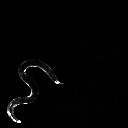

In [6]:
# Loading a test image from file
raw_image = cv2.imread('../data/processed_files/multiworm_feature_extraction/base_images/5_t065_ch01.jpg')
Image.fromarray(cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB))

## Getting Non-Edge Masks

### Loading the SAM2 Model Artifacts

In [7]:
# Setting the hardware we are working on
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Current hardware device type: {device}')

# Loading the mask generating pipeline from Hugging Face
mask_generator = pipeline('mask-generation', model = 'facebook/sam2.1-hiera-large', device = device)

Current hardware device type: mps


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

### Creating Helper Functions to Produce Non-Edge Masks

In [8]:
# Checking whether a bounding box touches any image boundary
def _is_on_edge(x, y, w, h, img_width, img_height):
    # Checking the left edge
    if x <= 0:
        return True

    # Checking the top edge
    if y <= 0:
        return True

    # Checking the right edge
    if (x + w) >= img_width - 1:
        return True

    # Checking the bottom edge
    if (y + h) >= img_height - 1:
        return True

    # Returning False if no edge was touched
    return False

# Determining the valid microscope imaging area from an RGB/grayscale image
def get_valid_imaging_area(image, margin=5, max_iterations=100):
    # Converting to grayscale if the input has 3 channels
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Binarizing the image using Otsu thresholding
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Finding external contours in the binary image
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Falling back to full-image valid area when no contours exist
    if not contours:
        return np.ones_like(gray, dtype=bool), False

    # Keeping only contours in a plausible area range
    valid_contours = [
        cnt for cnt in contours
        if 0.1 < cv2.contourArea(cnt) / (gray.shape[0] * gray.shape[1]) < 0.99
    ]

    # Falling back to full-image valid area when no plausible contour exists
    if not valid_contours:
        return np.ones_like(gray, dtype=bool), False

    # Selecting the largest valid contour as the imaging field
    largest_contour = max(valid_contours, key=cv2.contourArea)

    # Drawing the valid area as a binary mask
    valid_area_mask = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(valid_area_mask, [largest_contour], -1, 255, -1)

    # Eroding the valid area by 'margin' pixels to avoid edge artifacts
    if margin > 0:
        kernel = np.ones((3, 3), np.uint8)
        eroded_mask = valid_area_mask.copy()

        # Applying erosion iteratively with a safety stop
        for _ in range(min(margin, max_iterations)):
            temp_mask = cv2.erode(eroded_mask, kernel)
            if np.sum(temp_mask) < 1000:
                break
            eroded_mask = temp_mask

        valid_area_mask = eroded_mask

    # Returning a boolean valid-area mask and success flag
    return valid_area_mask > 0, True

# Producing non-edge masks from the HF mask-generation pipeline output
def get_nonedge_masks_hf(raw_image_bgr, mask_generator, margin=5, **mask_gen_kwargs):

    # Converting OpenCV BGR -> RGB to match model expectations
    image = cv2.cvtColor(raw_image_bgr, cv2.COLOR_BGR2RGB)
    img_height, img_width = image.shape[:2]

    # Converting to PIL image for Hugging Face pipeline input
    pil_image = Image.fromarray(image)

    # Running automatic mask generation
    outputs = mask_generator(image=pil_image, **mask_gen_kwargs)
    raw_masks = outputs.get("masks", [])

    # Normalizing HF mask outputs into boolean segmentation arrays
    segmentations = []
    for mask in raw_masks:
        # Handling tensor mask outputs
        if isinstance(mask, torch.Tensor):
            segmentation = mask.detach().cpu().numpy().astype(bool)

        # Handling PIL mask outputs
        elif isinstance(mask, Image.Image):
            segmentation = (np.array(mask) > 0)

        # Handling numpy/other array-like outputs
        else:
            segmentation = np.asarray(mask).astype(bool)

        # Keeping only masks that match the input image shape
        if segmentation.shape == (img_height, img_width):
            segmentations.append(segmentation)

    # Computing the valid imaging area used for edge filtering
    valid_area, success = get_valid_imaging_area(image, margin=margin)
    nonedge_masks = []

    # Preferred path: keep masks fully contained in valid imaging area
    if success:
        for segmentation in segmentations:
            if np.all(segmentation * valid_area == segmentation):
                nonedge_masks.append(segmentation)

    # Fallback path: remove masks that touch the image boundary
    else:
        for segmentation in segmentations:
            coords = np.where(segmentation)
            if len(coords[0]) == 0:
                continue

            # Computing bounding box around the mask
            y1, x1 = np.min(coords[0]), np.min(coords[1])
            y2, x2 = np.max(coords[0]), np.max(coords[1])
            h, w = (y2 - y1 + 1), (x2 - x1 + 1)

            # Keeping only masks whose bounding box is not on image edges
            if not _is_on_edge(x1, y1, w, h, img_width, img_height):
                nonedge_masks.append(segmentation)

    # Printing a compact debug summary of filtering behavior
    print(f"Mask debug: raw={len(segmentations)}, valid_area_success={success}, kept={len(nonedge_masks)}")

    # Returning outputs aligned with get_nonedge_masks(...) in the script
    return image, img_height, img_width, nonedge_masks

### Producing / Saving the Non-Edge Masks

In [9]:
# Checking whether cutouts have already been saved (ignoring .gitkeep)
cutouts_dir = Path(processed_files_dir) / "cutouts"
existing_cutouts = [
    path for path in cutouts_dir.iterdir() if path.name != '.gitkeep'
] if cutouts_dir.exists() else []

# Producing the non-edge masks only when cutouts don't already exist
if not existing_cutouts:
    image, img_height, img_width, nonedge_masks = get_nonedge_masks_hf(
        raw_image_bgr=raw_image,
        mask_generator=mask_generator,
        margin=5,
        points_per_batch=64,
        pred_iou_thresh=0.85,
        stability_score_thresh=0.85,
        stability_score_offset=0.85,
    )
    print(f"Image shape: {image.shape}, height={img_height}, width={img_width}")
    print(f"Non-edge masks: {len(nonedge_masks)}")
else:
    print(f"Cutouts already exist in {cutouts_dir}; skipping mask generation.")

Cutouts already exist in ../data/processed_files/multiworm_feature_extraction/cutouts; skipping mask generation.


In [10]:
# Saving each non-edge mask as a cropped JPEG cutout
def save_mask_cutouts(image, nonedge_masks, output_dir: Path):
    # Refreshing the output directory so each run starts clean
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Saving {len(nonedge_masks)} non-edge cutouts to {output_dir}")

    for i, mask in enumerate(nonedge_masks):
        
        # Getting bounding box coordinates from the mask pixel positions
        coords = np.where(mask)
        y1, x1 = np.min(coords[0]), np.min(coords[1])
        y2, x2 = np.max(coords[0]), np.max(coords[1])

        # Expanding the 2D boolean mask to 3 channels so it can be applied to an RGB image
        mask_3d = np.repeat(mask[:, :, np.newaxis], 3, axis=2)

        # Zeroing out all pixels outside the mask, then cropping to the tight bounding box
        cutout = image * mask_3d
        cutout = cutout[y1:y2+1, x1:x2+1]

        # Saving the cropped cutout as a JPEG (converting back to BGR for OpenCV)
        cutout_path = output_dir / f"{i}.jpg"
        cv2.imwrite(str(cutout_path), cv2.cvtColor(cutout, cv2.COLOR_RGB2BGR))

# Saving the non-edge mask cutouts only when the cutouts directory is empty or missing
if not existing_cutouts:
    save_mask_cutouts(image, nonedge_masks, cutouts_dir)
else:
    print(f"Cutouts already exist in {cutouts_dir}; skipping save.")

Cutouts already exist in ../data/processed_files/multiworm_feature_extraction/cutouts; skipping save.


## Classifying the Worm with Lilly Guisnet's Custom Classifier

In [11]:
# Setting the Hugging Face repo for the classifier model
# (Note: This model was created by Lilly Guisnet and fine-tuned on C. elegans images)
HF_CLASSIFIER_REPO = 'lillyguisnet/celegans-classifier-vit-h-14-finetuned'

# Loading the custom image processor / image classifier from Hugging Face
image_classification_processor = AutoImageProcessor.from_pretrained(HF_CLASSIFIER_REPO)
image_classification_model = AutoModelForImageClassification.from_pretrained(HF_CLASSIFIER_REPO)

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

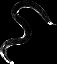

In [12]:
# Loading the cutout from a local file
cutout = Image.open(cutouts_dir / '0.jpg')
cutout

In [13]:
# Preparing the cutout image
inputs = image_classification_processor(images = cutout, return_tensors = 'pt')

# Processing the cutout through the model
with torch.no_grad():
    outputs = image_classification_model(**inputs)
logits = outputs.logits

# Producing the prediction (1 = worm, 0 = not a worm)
pred = logits.argmax(-1).item()

if pred == 1:
    print('We got a worm!')
elif pred == 0:
    print('No worm here!')

We got a worm!
